In [ ]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import sys
import numpy as np

import seaborn as sns
import jax.scipy.special as jsp
import seaborn as sns
from jax import lax, jit, grad
from scipy.optimize import minimize


sns.set_palette('rocket')
sns.set(font_scale=1.5)

In [ ]:
kappa= 1.0
chi = 1.0
dt = 0.01

b = 1.0
all_chi = []
gamma = 2.0 - 1/b

# solve chi0 eqn
# solve chi(t)

for t in range(250):
  all_chi += [chi]
  chi = chi - dt / jnp.sqrt( kappa + chi**(-gamma) )
  sys.stdout.write(f'\r chi = {chi}')

 chi = nan

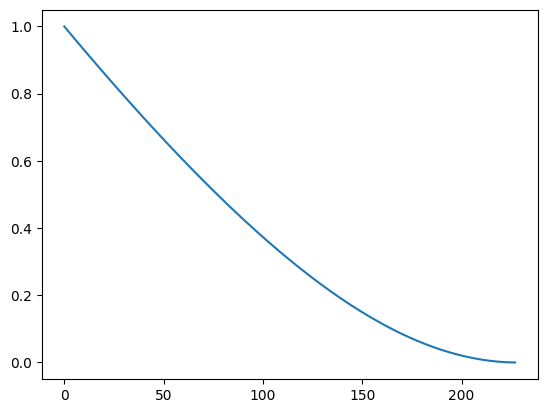

In [ ]:
plt.plot(all_chi)
plt.show()

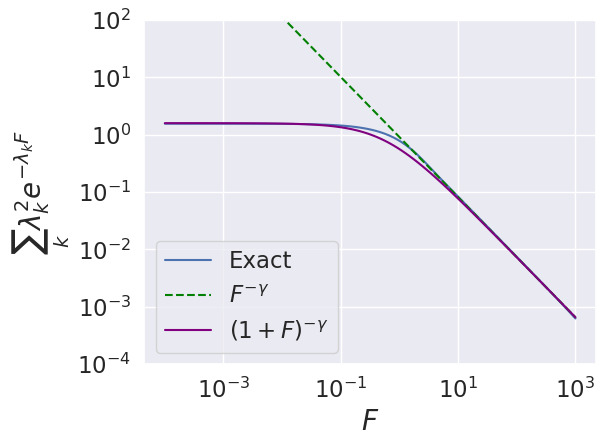

In [ ]:
# plot SGD function sum_k lambda_k e^{-lambda_k F}

sns.set_palette('rocket')
sns.set(font_scale=1.5)
Fvals = jnp.logspace(-4,3,100)
N = 8000
b = 1.05

spec = jnp.linspace(1,N,N)**(- b )

F_func = jnp.exp( - jnp.outer(Fvals, spec)) @ spec**2

gamma = 2.0 - 1/b
plt.loglog(Fvals, F_func, label = 'Exact')
plt.loglog(Fvals, Fvals**(- gamma ) /(2*b-1.0) , '--', color = 'green', label = r'$F^{-\gamma}$')
plt.loglog( Fvals, ( 1.0/jsp.zeta(2*b,1.0) + Fvals / (2*b-1.0)**(-1.0/gamma) )**(- gamma ) , color = 'purple', label = r'$(1+F)^{-\gamma}$')
plt.ylim([1.0e-4,100])
plt.xlabel(r'$F$',fontsize = 20)
plt.ylabel(r'$\sum_k \lambda_k^2 e^{-\lambda_k F}$', fontsize =20)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from scipy.optimize import minimize
import numpy as np
import jax.numpy as jnp
from jax import grad, jit, lax
import matplotlib.pyplot as plt

In [ ]:
@jit
def loss_fn(etas, m, spec, w_star, T, sigma):

  c = w_star**2
  """
  for t in range(T):
    c = (1-spec*etas[t])**2 * c + sigma**2/m * spec
  """
  def update_fn(c, eta):

    c = (1 - spec * eta)**2 * c + eta**2/m * spec**2*c +  eta**2/m * spec * jnp.sum(spec*c) + eta**2 * sigma**2/m * spec
    #c = (1 - spec * eta)**2 * c + eta**2 * sigma**2/m * spec
    return c, jnp.sum(spec*c)

  c, loss = lax.scan(update_fn, c, etas)
  return loss[-1]


jac = jit( grad(loss_fn, 0) )


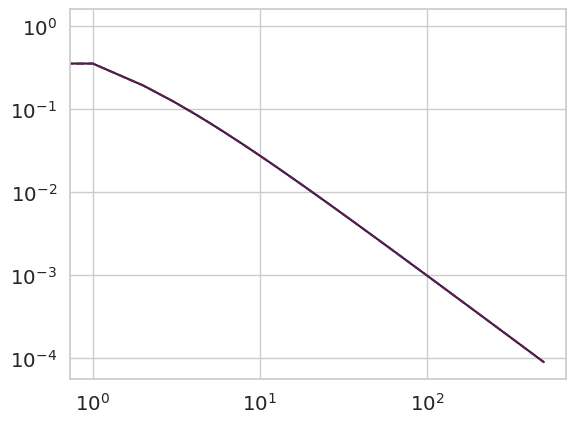

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.22305619716644287
        x: [ 1.631e-01  1.707e-01 ...  1.975e-02  1.936e-02]
      nit: 42
      jac: [-4.003e-06 -3.177e-06 ...  2.781e-05 -8.843e-05]
     nfev: 60
     njev: 60
 hess_inv: <500x500 LbfgsInvHessProduct with dtype=float64>


In [ ]:
m = 1
N = 500
b = 1.25
a = 1.5
spec = jnp.linspace(1,N,N)**( - b)
w_star = jnp.linspace(1,N,N)**(- (a-b)/2 )

plt.loglog(w_star**2*spec)
plt.loglog(jnp.linspace(1,N,N)**(-a),'--')
plt.show()

sigma = 0.5
T = 500

bounds = [(0, 2.0) for t in range(T)]

result = minimize(loss_fn, x0= 0.5*jnp.ones(T), args = (m, spec, w_star, T, sigma) , jac=jac, bounds = bounds, tol=1e-12)
print(result)

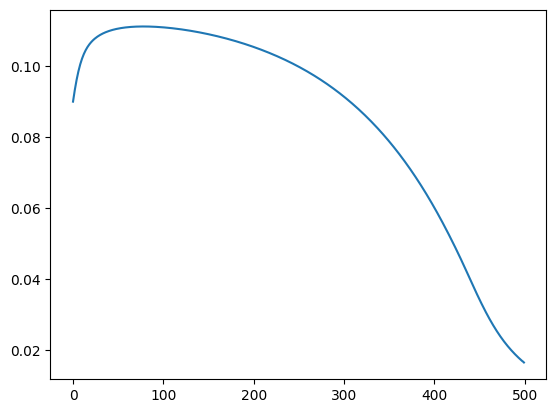

In [ ]:
plt.plot(result.x)
plt.show()

In [ ]:
Tvals = [100,200,500, 1000, 2000, 5000]

N = 500
b = 1.2
a = 2.5
spec = jnp.linspace(1,N,N)**( - b )
w_star = jnp.linspace(1,N,N)**(- (a-b)/2 )

sigma = 0.1
m = 4
all_etas = []
for i, T in enumerate(Tvals):
  print(f"T = {T}")
  bounds = [(0, 2.0) for t in range(T)]
  result = minimize(loss_fn, x0= 1.0*jnp.ones(T), args = (m, spec, w_star, T, sigma), jac=jac, bounds = bounds, tol=1e-8)
  print(result.success)
  all_etas += [result.x]

T = 100
True
T = 200
True
T = 500
True
T = 1000
True
T = 2000
True
T = 5000
True


In [ ]:
print(b)
print(a)

1.2
2.5


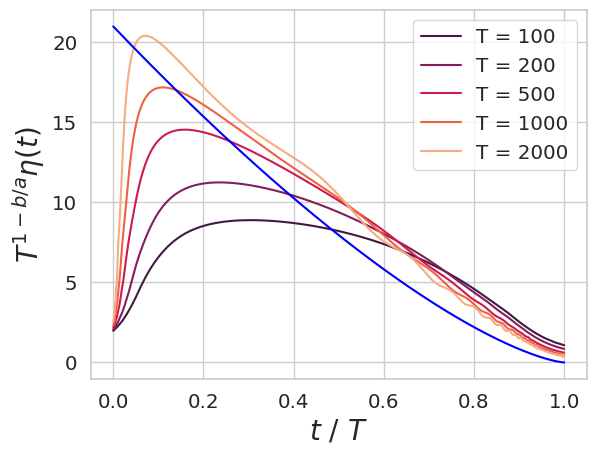

In [ ]:
sns.set(font_scale=1.3)
sns.set_style("whitegrid")
sns.set_palette("rocket", n_colors=len(all_etas))
for i, etas in enumerate(all_etas):
  plt.plot(jnp.linspace(0, 1, len(etas)), Tvals[i]**(1-b/a) * etas , color = f'C{i}', label = f'T = {Tvals[i]}')

plt.plot( jnp.linspace(0, 1, len(etas)), 21*(1-jnp.linspace(0, 1, len(etas)))**(2*b-1), color = 'blue' )
plt.legend()
plt.xlabel(r'$t \ / \ T$', fontsize = 20)
plt.ylabel(r'$T^{1-b/a} \eta(t)$', fontsize = 20)
plt.show()

In [ ]:
def momentum_sgd(etas, m, spec, w_star, T, sigma, beta = 0.25):

  c = w_star**2
  r = jnp.zeros(len(c))
  v = jnp.zeros(len(c))

  def update_fn(vars, eta):
    c, r, v = vars
    c_new = c - 2*eta*r + eta**2 * v
    r_new = beta*r - beta*eta*v + (1-beta)*spec*(c-eta*r) - (1-beta)* eta * spec * (r-eta*v)
    v_new = beta**2* v + 2 * (1-beta) * beta * spec * (r - eta*v) + (1-beta)**2 * ( (m+1)/m* spec**2 * c_new + 1/m * spec*jnp.sum(c_new * spec) + sigma**2/m * spec )

    return [c_new,r_new,v_new], jnp.sum(spec*c)

  c, loss = lax.scan(update_fn, [c,r,v], etas)

  return loss

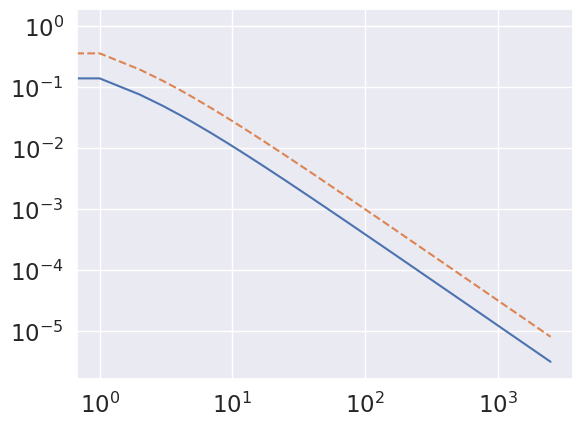

In [ ]:
m = 4
N = 2500
b = 1.1
a = 1.5
spec = jnp.linspace(1,N,N)**( - b)
w_star = jnp.linspace(1,N,N)**(- (a-b)/2 )

w_star = w_star / jnp.sqrt( jnp.sum( w_star**2*spec ) )

plt.loglog(w_star**2*spec)
plt.loglog(jnp.linspace(1,N,N)**(-a),'--')
plt.show()

sigma = 0.4
beta = 0.8
T = 2500

etas = 0.75*jnp.ones(T)
loss = momentum_sgd(etas, m, spec, w_star, T, sigma, beta = beta)

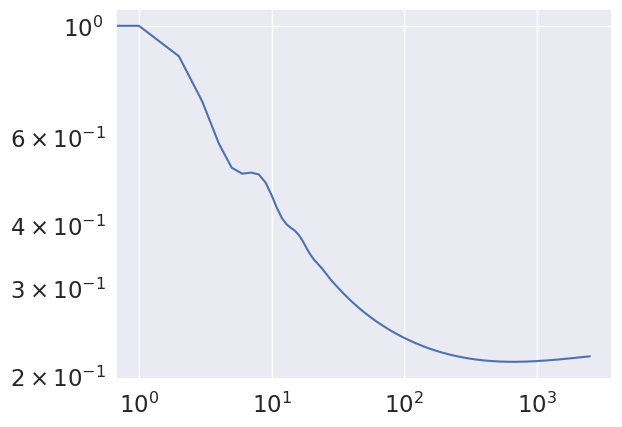

In [ ]:
plt.loglog(loss)
plt.show()

In [ ]:
betas = [0.0, 0.25, 0.5, 0.75, 0.9, 0.95,0.99,0.995,0.999]
T = 10000
m = 8
etas = 0.5*jnp.ones(T)
sigma = 0.8

losses = [momentum_sgd(etas, m, spec, w_star, T, sigma, beta = beta) for beta in betas]

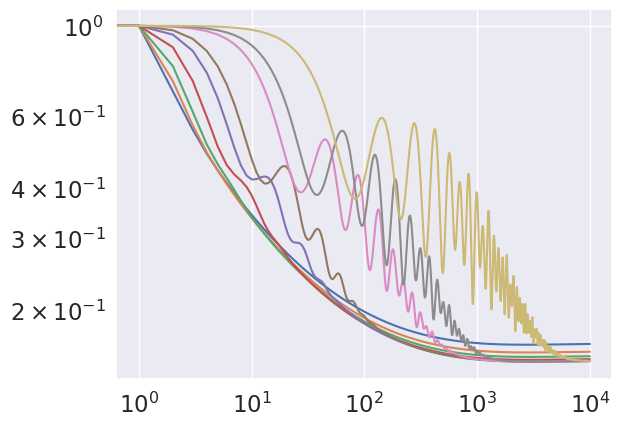

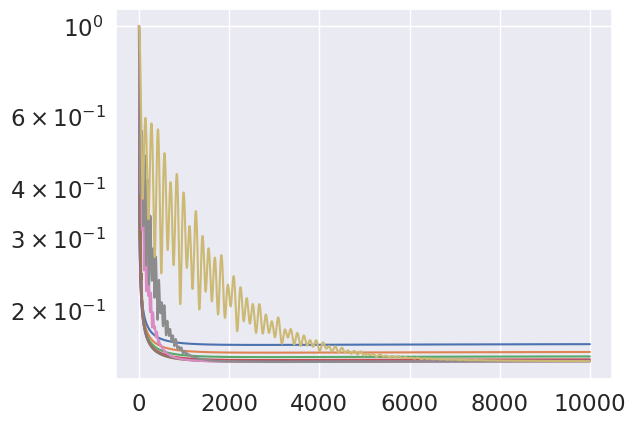

In [ ]:
for i, loss in enumerate(losses):
  plt.loglog(loss)
plt.show()

for i, loss in enumerate(losses):
  plt.semilogy(loss)
plt.show()

In [ ]:
def momentum_bias(eta_betas, m, spec, w_star, T, sigma):

  Delta = w_star
  v = jnp.zeros(len(Delta))

  def update_fn(vars, eta_beta):
    Delta, v = vars
    eta1, eta2, beta = eta_beta

    v_new = beta*v +  spec * Delta
    Delta_new = Delta - eta1 * spec*Delta - eta2 * v_new

    return [Delta_new , v_new], jnp.sum(spec*Delta**2)

  c, loss = lax.scan(update_fn, [Delta, v], eta_betas)

  return loss

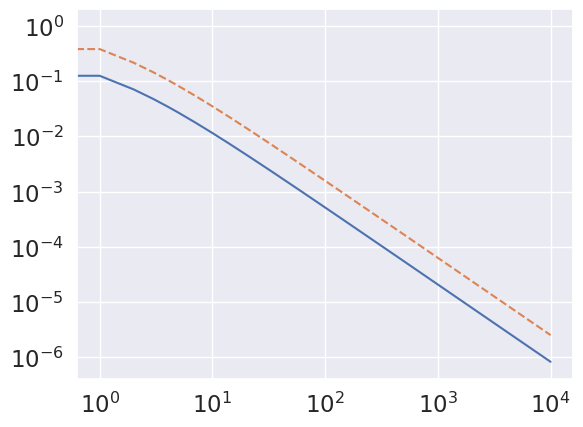

In [ ]:
T = 10000
m = 8
etas = 0.5*jnp.ones(T)
sigma = 0.8
eta_betas = np.zeros((T,3))

a = 1.4
b = 2.0

N = 10000
spec = np.linspace(1,N,N)**(-b)

w_star = jnp.linspace(1,N,N)**(- (a-b)/2 )
w_star = w_star / jnp.sqrt( jnp.sum( w_star**2*spec ) )

plt.loglog(w_star**2*spec)
plt.loglog(jnp.linspace(1,N,N)**(-a),'--')
plt.show()

beta = 0.99
eta1 = 0.1
eta2 = 0.2
eta_betas[:,0] = eta1 * np.ones(T)
eta_betas[:,1] = eta2 * np.ones(T)
eta_betas[:,-1] = beta * np.ones(T)



loss = momentum_bias(   eta_betas, m,  spec, w_star, T, sigma)


eta_betas[:,0] = eta1 * np.ones(T)
eta_betas[:,1] = 0.0 * np.ones(T)
eta_betas[:,-1] = np.zeros(T)

loss_zero_beta = momentum_bias(   eta_betas, m,  spec, w_star, T, sigma)


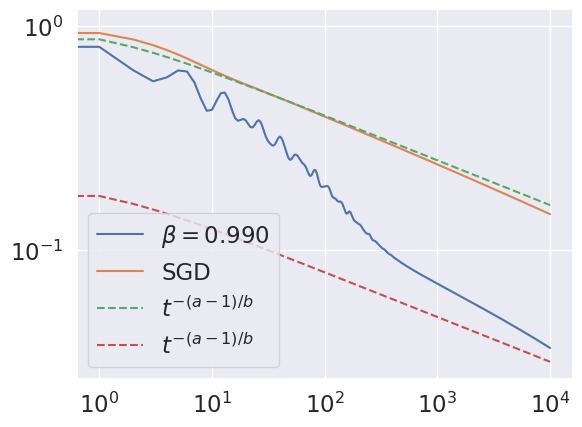

In [ ]:
plt.loglog(loss, label = r'$\beta=%0.3f$' % beta)

plt.loglog(loss_zero_beta, label = 'SGD')
plt.loglog( jnp.linspace(1,T,T)**(-(a-1)/b), '--', label = r'$t^{-(a-1)/b}$')
plt.loglog( 0.2*jnp.linspace(1,T,T)**(-(a-1)/b), '--', label = r'$t^{-(a-1)/b}$')

plt.legend()
plt.show()

In [ ]:
betas = [0.5, 0.8, 0.9, 0.99, 0.995, 0.999]
eta1 = 0.25
eta2= 0.5

T=50000

eta_betas = np.zeros((T,3))


losses = []
for i, beta in enumerate(betas):

  eta_betas[:,0] = eta1 * np.ones(T)
  eta_betas[:,1] = eta2 * np.ones(T)
  eta_betas[:,-1] = beta * np.ones(T)
  loss = momentum_bias(   eta_betas, m,  spec, w_star, T, sigma)
  losses += [loss]

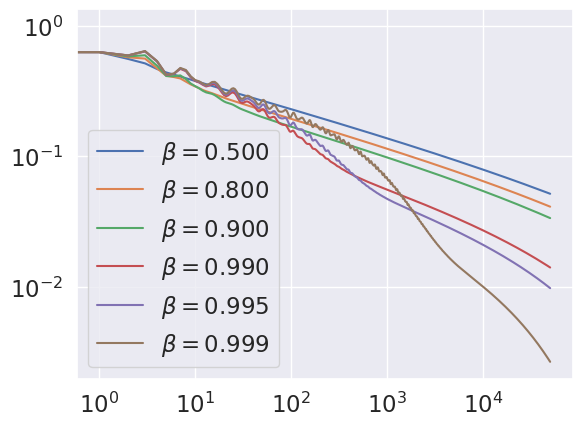

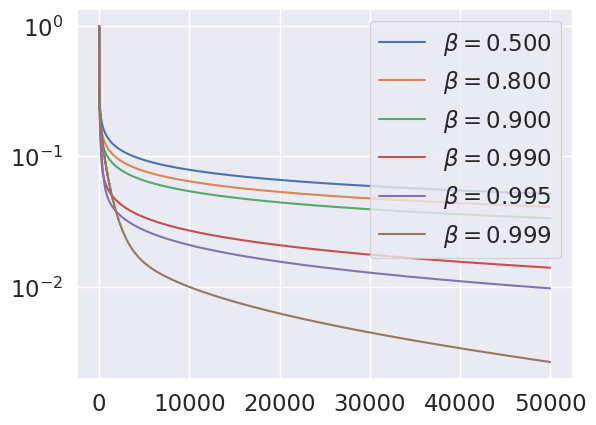

In [ ]:
for i, loss in enumerate(losses):
  plt.loglog(loss, label = r'$\beta = %0.3f$' % betas[i])
plt.legend()
plt.show()

for i, loss in enumerate(losses):
  plt.semilogy(loss, label = r'$\beta = %0.3f$' % betas[i])
plt.legend()
plt.show()

In [ ]:
max_real = []
betas_th = np.linspace(0.0, 1.0, 100)

spectrum = [1.0, 0.1, 0.01, 0.001, 0.0001]

for j, eig in enumerate(spectrum):
  max_j = []
  for i, beta in enumerate(betas_th):

    M1 = np.array([ [1.0 - eta1*eig - eta2*eig, - eta2*beta], [eig, beta] ])
    eigs = jnp.linalg.eigvals(M1)
    max_j += [np.amax(eigs.real)]

  max_real += [max_j]

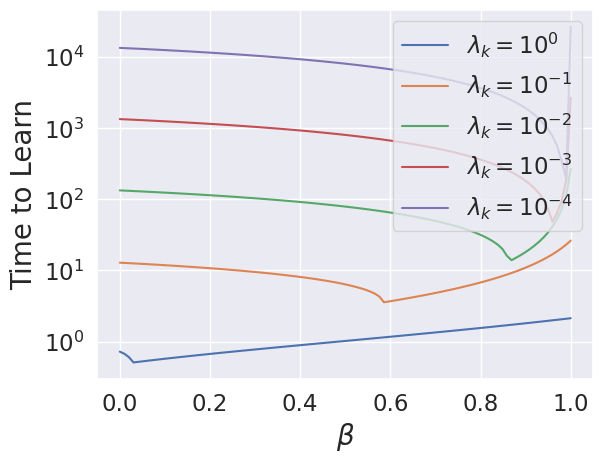

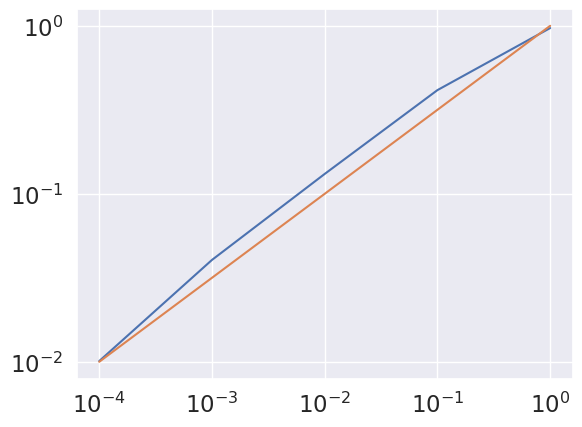

In [ ]:
min_vals = []
for i, max in enumerate(max_real):

  plt.semilogy(betas_th, -jnp.log(np.array(max))**(-1.0), label = r'$\lambda_k = 10^{%d}$' % np.log10(spectrum[i]))
  min_vals += [betas_th[np.argmin( -jnp.log(np.array(max))**(-1.0) )]]
plt.legend()
plt.xlabel(r'$\beta$', fontsize = 20)
plt.ylabel(r'Time to Learn',fontsize = 20)
plt.show()

plt.loglog(spectrum, 1.0 - np.array(min_vals))
plt.loglog( spectrum, np.array(spectrum)**(0.5) )
plt.show()

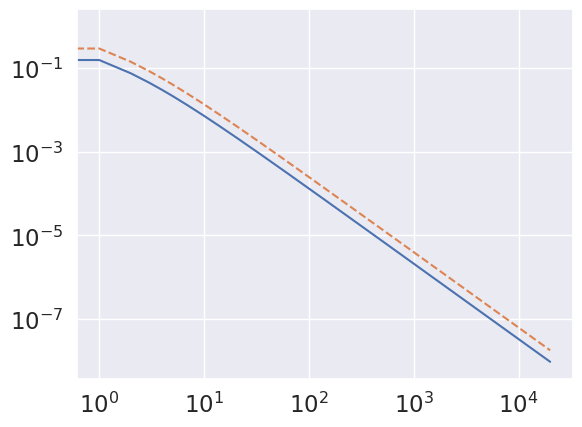

In [ ]:
T = 5000
m = 8
etas = 0.5*jnp.ones(T)
sigma = 0.8
eta_betas = np.zeros((T,3))

a = 1.8
b = 3.0

N = 20000
spec = np.linspace(1,N,N)**(-b)

w_star = jnp.linspace(1,N,N)**(- (a-b)/2 )
w_star = w_star / jnp.sqrt( jnp.sum( w_star**2*spec ) )

plt.loglog(w_star**2*spec)
plt.loglog(jnp.linspace(1,N,N)**(-a),'--')
plt.show()

beta = 1.0
eta1 = 0.0
eta2 = 0.7
eta_betas[:,0] = eta1 * np.ones(T)
eta_betas[:,1] = eta2 * np.ones(T)
eta_betas[:,-1] = beta * (1 - ( 1.0 + np.linspace(1,T,T) )**(-1.0) )



loss = momentum_bias(   eta_betas, m,  spec, w_star, T, sigma )


beta = 0.9
eta_betas[:,0] = eta1 * np.ones(T)
eta_betas[:,1] = eta2 * np.ones(T)
eta_betas[:,-1] = beta



loss_no_anneal = momentum_bias(   eta_betas, m,  spec, w_star, T, sigma)



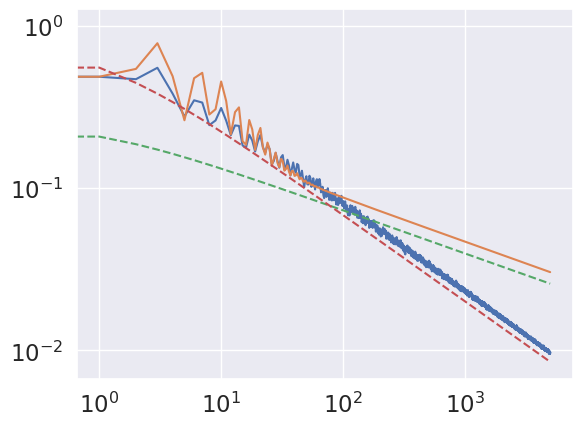

In [ ]:
plt.loglog(loss)
plt.loglog(loss_no_anneal)
plt.loglog( 0.25*jnp.linspace(1,T,T)**(-(a-1)/b), '--')
plt.loglog( 0.8 * jnp.linspace(1,T,T)**(-2 * (a-1)/b), '--')
plt.show()

In [ ]:
exponents = [0.25,0.5,0.8, 1.0, 1.2, 1.5, 2.0]

losses = []
for i, exponent in enumerate(exponents):


  beta = 1.0
  eta1 = 0.0
  eta2 = 0.1
  eta_betas[:,0] = eta1 * np.ones(T)
  eta_betas[:,1] = eta2 * np.ones(T)
  eta_betas[:,-1] = beta * (1.0 - ( 1.0 + np.linspace(1,T,T) )**(-exponent) )
  loss = momentum_bias(   eta_betas, m,  spec, w_star, T, sigma)

  losses += [loss]


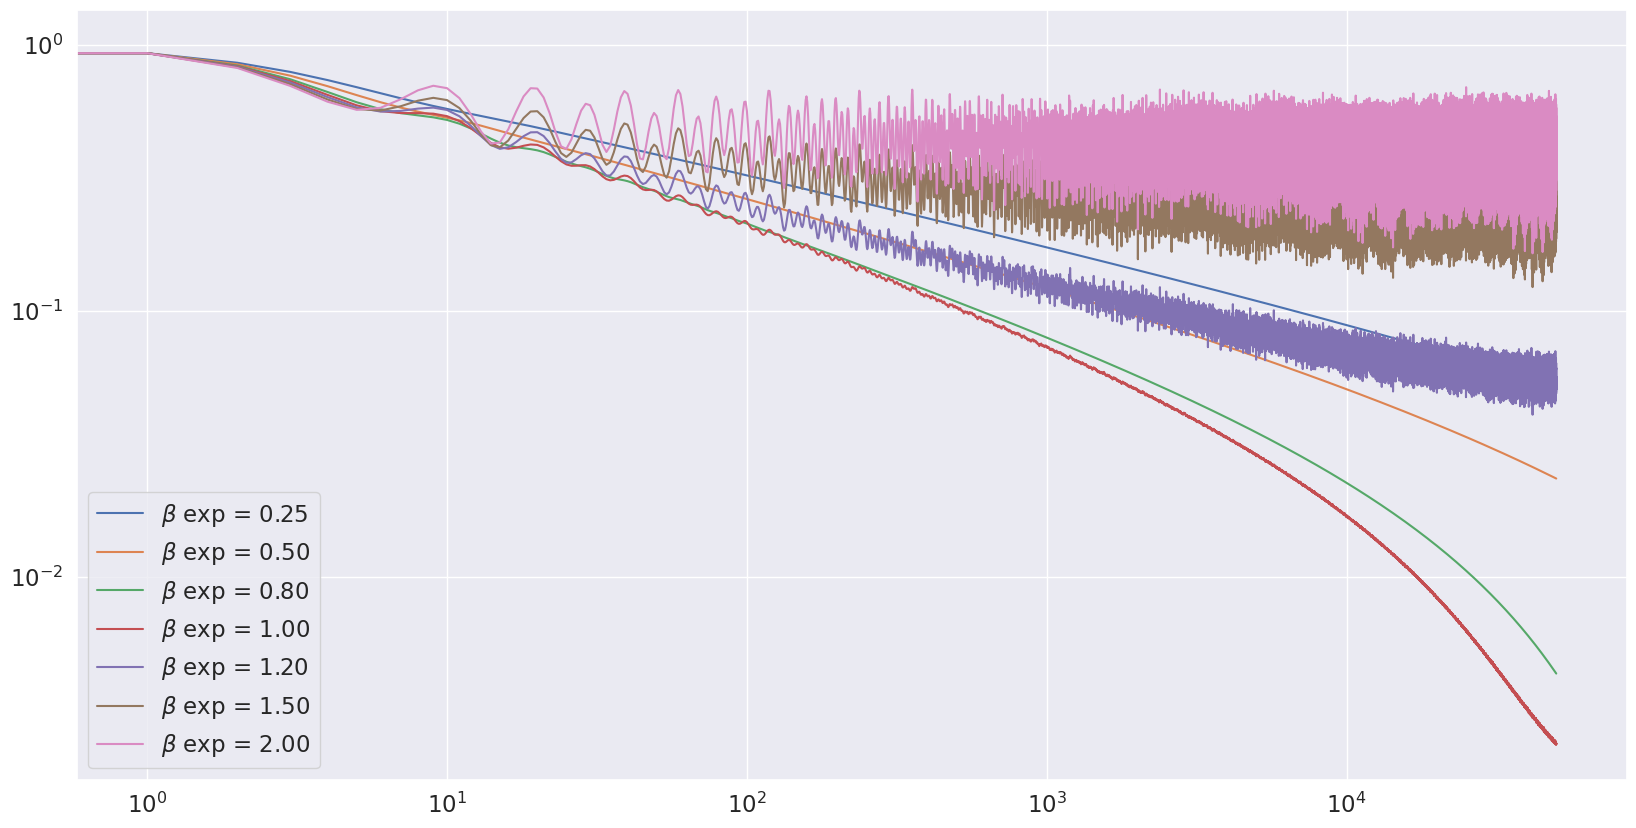

In [ ]:
plt.figure(figsize = (20,10))
for i, loss in enumerate(losses):
  plt.loglog(loss, label = r'$\beta$ exp = $%0.2f$' % exponents[i])

plt.legend()
plt.show()

In [ ]:
def diagonalize(eta, lamb, beta):

  M = np.array( [[1 - 2*eta*lamb , - eta*beta ], [ lamb, beta  ] ])
  return np.linalg.eigvals(M)

In [ ]:
betas = np.linspace(0,1,1000)
lamb = 0.1
eta = 0.25
eigs = [diagonalize(eta, lamb, beta) for beta in betas]

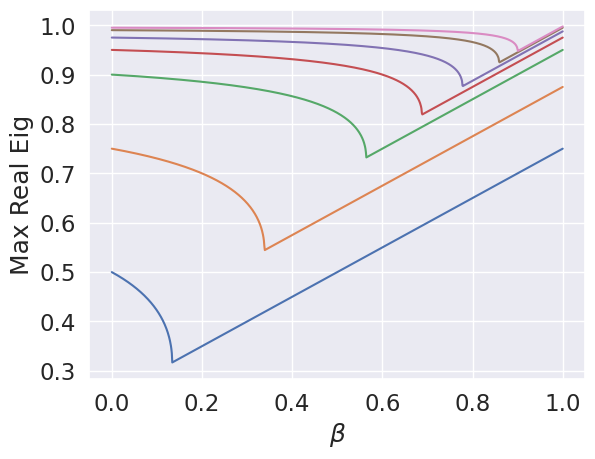

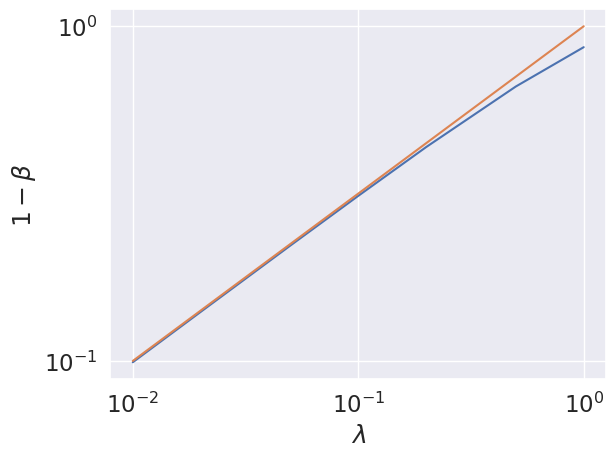

In [ ]:

lambs = [1.0, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01]

eigs_all = [[diagonalize(eta, lamb, beta) for beta in betas] for lamb in lambs]
eigs_all = np.array(eigs_all)


mins = []
for i, eigs in enumerate(eigs_all):
  mins += [ betas[np.argmin(np.amax(eigs.real, axis = -1))] ]
  plt.plot(betas, np.amax(eigs.real, axis = -1))
plt.xlabel(r'$\beta$')
plt.ylabel(r'Max Real Eig')
plt.show()

plt.loglog(lambs, 1.0 - np.array(mins))
plt.loglog(lambs, np.array(lambs)**(0.5))
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$1-\beta$')
plt.show()

In [ ]:
exponents = [0.25,0.5,0.8, 1.0, 2.0]
T = 10000
m = 8
etas = 0.5*jnp.ones(T)
sigma = 0.8
eta_betas = np.zeros((T,3))

a = 1.4
b = 1.6

N = 10000
spec = np.linspace(1,N,N)**(-b)

w_star = jnp.linspace(1,N,N)**(- (a-b)/2 )
w_star = w_star / jnp.sqrt( jnp.sum( w_star**2*spec ) )

losses = []
for i, exponent in enumerate(exponents):


  beta = 1.0
  eta1 = 0.4
  eta2 = 0.6
  eta_betas[:,0] = eta1 * np.ones(T)
  eta_betas[:,1] = eta2 * np.ones(T)
  eta_betas[:,-1] = beta * (1.0 - ( 1.0 + np.linspace(1,T,T) )**(-exponent) )
  loss = momentum_bias(   eta_betas, m,  spec, w_star, T, sigma)

  losses += [loss]


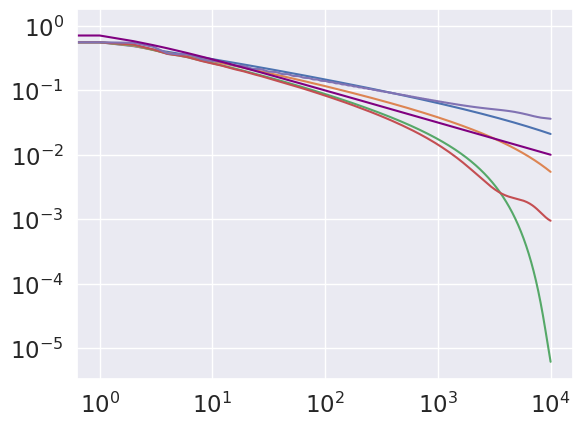

In [ ]:
for i, loss in enumerate(losses):
  plt.loglog(loss)
plt.loglog(np.linspace(1,T,T)**(- 2*(a-1)/b ) , color = 'purple')
plt.show()

In [ ]:
eta2s = [0.0, 0.85]
T = 80000
m = 8
sigma = 0.8
eta_betas = np.zeros((T,3))

a = 1.6
b = 1.8


N = 50000
spec = np.linspace(1,N,N)**(-b)

w_star = jnp.linspace(1,N,N)**(- (a-b)/2 )
w_star = w_star / jnp.sqrt( jnp.sum( w_star**2*spec ) )
exponent = 1.0

beta = 1.0
eta1 = 1.0

losses = []
for i, eta2 in enumerate(eta2s):


  eta_betas[:,0] = eta1 * np.ones(T)
  eta_betas[:,1] = eta2 * np.ones(T)
  eta_betas[:,-1] = beta * (1.0 - ( 1.0 + np.linspace(1,T,T) )**(-exponent) )
  loss = momentum_bias(   eta_betas, m,  spec, w_star, T, sigma)

  losses += [loss]


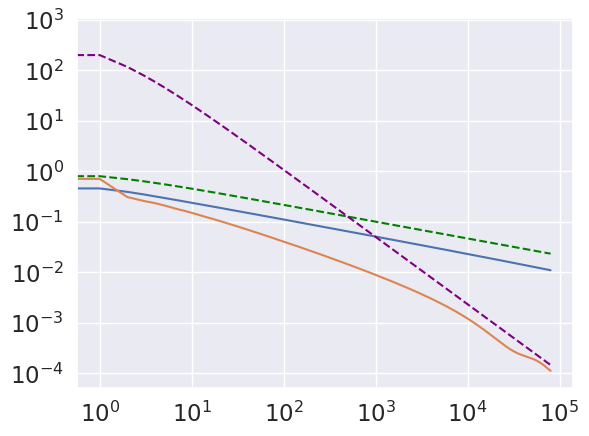

In [ ]:
for i, loss in enumerate(losses):
  plt.loglog(loss)

plt.loglog(np.linspace(1,T,T)**(- (a-1)/b ) , '--', color = 'green')
plt.loglog( 500* np.linspace(1,T,T)**(- (a-1)/b - 1    ) ,'--', color = 'purple')
plt.show()

In [ ]:
eta2s = [0.0, 0.85]
T = 20000
m = 8
sigma = 0.8
eta_betas = np.zeros((T,3))

a = 1.6
b = 1.8


N = 50000
spec = np.linspace(1,N,N)**(-b)

w_star = jnp.linspace(1,N,N)**(- (a-b)/2 )
w_star = w_star / jnp.sqrt( jnp.sum( w_star**2*spec ) )
exponent = 1.0

beta = 0.9999
eta1 = 1.0

losses = []
for i, eta2 in enumerate(eta2s):


  eta_betas[:,0] = eta1 * np.ones(T)
  eta_betas[:,1] = eta2 * np.ones(T)
  eta_betas[:,-1] = beta * np.ones(T)
  loss = momentum_bias(   eta_betas, m,  spec, w_star, T, sigma)

  losses += [loss]


beta = 1.0
losses_ann = []
for i, eta2 in enumerate(eta2s):


  eta_betas[:,0] = eta1 * np.ones(T)
  eta_betas[:,1] = eta2 * np.ones(T)
  eta_betas[:,-1] = beta * (1- np.linspace(1,T,T)**(-1.0))
  loss = momentum_bias(   eta_betas, m,  spec, w_star, T, sigma)

  losses_ann += [loss]


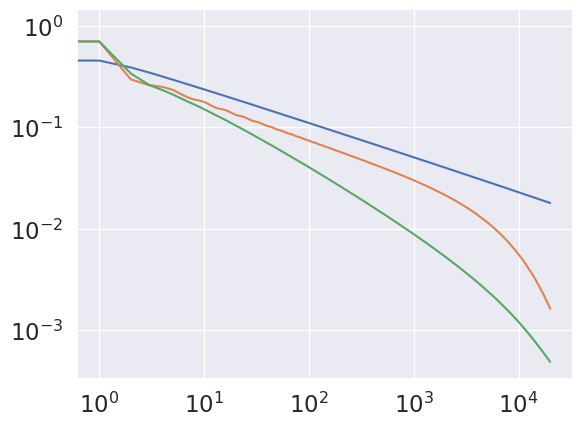

In [ ]:
plt.loglog(losses[0])
plt.loglog(losses[1])
plt.loglog(losses_ann[1])
plt.show()

In [ ]:
def momentum_loss_dynamics(eta_betas, m, spec, w_star, T, sigma):


  def update_fn(vars, eta_beta):
    C, R, V = vars
    eta, beta = eta_beta

    C_new = C - 2*eta*R + eta**2 * V
    R_new = (1-beta) * ( R - eta * V  ) + beta * spec * C_new
    g_corr = (m+1)/m * spec**2 * C_new + 1/m * jnp.sum(C_new * spec)*spec + sigma**2/m * spec
    V_new = (1-beta)**2 * V + 2*beta*(1-beta) * spec * ( R - eta*V ) + beta**2 * g_corr

    return [C_new, R_new, V_new], jnp.sum(spec * C)

  beta = eta_betas[-1,0]
  C0 = w_star**2
  R0 = beta*spec*C0
  V0 = beta**2 * (m+1)/m * spec**2*C0 + beta**2/m * spec*jnp.sum(C0 * spec) + beta**2*sigma**2/m * spec
  #R0 = jnp.zeros(len(C0) )
  #V0 = jnp.zeros(len(C0) )
  c, loss = lax.scan(update_fn, [ C0 , R0 ,  V0 ], eta_betas)

  return loss


def sgd_loss_dynamics(etas, m, spec, w_star, T, sigma):

  def update_fn(C, eta):

    C_new = C - 2*eta*spec*C + (m+1)/m * eta**2 * spec**2 * C + eta**2/m * jnp.sum(C * spec)*spec + sigma**2 * eta**2 / m * spec
    return C_new, jnp.sum(spec * C)

  C0 = w_star**2
  c, loss = lax.scan(update_fn, C0, etas)

  return loss

def momentum_bias_dynamics(eta_betas, m, spec, w_star, T, sigma):


  def update_fn(vars, eta_beta):
    Delta, v = vars
    eta, beta = eta_beta

    Delta_new = Delta - eta*v
    v_new = (1-beta)*v + beta * spec * Delta_new
    #R_new = (1-beta) * ( R - eta * V  ) + beta * spec * C_new
    #g_corr = (m+1)/m * spec**2 * C_new + 1/m * jnp.sum(C_new * spec)*spec + sigma**2/m * spec
    #V_new = (1-beta)**2 * V + 2*beta*(1-beta) * spec * ( R - eta*V ) + beta**2 * g_corr

    return [Delta_new, v_new], jnp.sum(spec * Delta**2)

  Delta = w_star
  v = beta * spec * Delta
  c, loss = lax.scan(update_fn, [ Delta, v ], eta_betas)

  return loss

In [ ]:
def momentum_loss_dynamics_wd(controls, m, spec, w_star, T, sigma):
  """Momentum SGD with weight decay zeta(t) control.
  controls: (T, 3) array with columns [eta, beta, zeta]

  C_{t+1} = C_t - 2*eta*R_t - 2*zeta*lambda*C_t + 2*eta*zeta*lambda*R_t + eta^2*V_t + zeta^2*<g^2>
  R_{t+1} = (1-beta)*(R_t - eta*V_t - zeta*lambda*R_t) + beta*(lambda*C_t - eta*lambda*R_t - zeta*<g^2>)
  V_{t+1} = (1-beta)^2*V_t + 2*beta*(1-beta)*lambda*R_t + beta^2*<g^2>
  <g^2> = (m+1)/m * lambda^2 * C_t + 1/m * lambda * sum_k(lambda_k * C_k) + sigma^2/m * lambda
  """

  def update_fn(vars, ctrl):
    C, R, V = vars
    eta, beta, zeta = ctrl

    g_sq = (m+1)/m * spec**2 * C + 1/m * spec * jnp.sum(spec * C) + sigma**2/m * spec

    C_new = C - 2*eta*R - 2*zeta*spec*C + 2*eta*zeta*spec*R + eta**2*V + zeta**2*g_sq
    R_new = (1-beta)*(R - eta*V - zeta*spec*R) + beta*(spec*C - eta*spec*R - zeta*g_sq)
    V_new = (1-beta)**2*V + 2*beta*(1-beta)*spec*R + beta**2*g_sq

    return [C_new, R_new, V_new], jnp.sum(spec * C)

  beta0 = controls[0, 1]
  C0 = w_star**2
  R0 = beta0 * spec * C0
  V0 = beta0**2 * ((m+1)/m * spec**2 * C0 + 1/m * spec * jnp.sum(C0 * spec) + sigma**2/m * spec)

  _, loss = lax.scan(update_fn, [C0, R0, V0], controls)

  return loss

In [ ]:
betas = [0.5, 0.8, 0.9, 0.99, 0.999, 0.99999]
eta1 = 0.1
m = 512
T=100000


a = 1.4
b = 1.8


sigma = 0.1

N = 10000
spec = np.linspace(1,N,N)**(-b)

w_star = jnp.linspace(1,N,N)**(- (a-b)/2 )
w_star = w_star / jnp.sqrt( jnp.sum( w_star**2*spec ) )

eta_betas = np.zeros((T,2))


losses = []
for i, beta in enumerate(betas):

  eta_betas[:,0] = eta1 * np.ones(T)
  eta_betas[:,-1] = beta * (1.0 - jnp.linspace(1,T,T)**(-1.0))
  loss = momentum_loss_dynamics(eta_betas, m,  spec, w_star, T, sigma)
  losses += [loss]

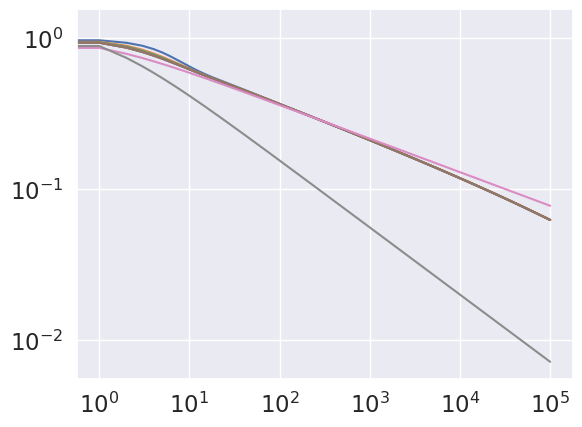

In [ ]:
for i, loss in enumerate(losses):
  plt.loglog(loss)
plt.loglog( 1.0*jnp.linspace(1,T,T)**(- (a-1)/b))
plt.loglog( 1.2*jnp.linspace(1,T,T)**(- 2*(a-1)/b))
plt.show()

In [ ]:

eta = 0.8
beta = 0.8

T = 500

eta_betas = np.zeros((T,2))

eta_betas[:,0] = eta * np.ones(T)
eta_betas[:,-1] = beta * np.ones(T)

a = 2.25
b = 1.75
m = 16

sigma = 0.25

N = 5000
spec = np.linspace(1,N,N)**(-b)

w_star = jnp.linspace(1,N,N)**(- (a-b)/2 )
w_star = w_star / jnp.sqrt( jnp.sum( w_star**2*spec ) )


@jit
def loss_fn_momentum(eta_betas, m, spec, w_star, sigma, kappa = 1e-4):

  eta_mat = eta_betas.reshape((T,2))
  loss_val = momentum_loss_dynamics(eta_mat, m, spec, w_star, T, sigma)[-1]
  reg = kappa * jnp.sum( (eta_mat[1:,:] - eta_mat[:-1, :])**2 )
  return loss_val + reg

jac = jit(grad(loss_fn_momentum, 0))

bounds = [(0, 1.0) for t in range(2*T)]

x0 = eta_betas.reshape((2*T,))

result = minimize(loss_fn_momentum, x0=x0, args = (m, spec, w_star, sigma) , jac=jac, bounds = bounds, tol=1e-10)
print(result)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.004461496602743864
        x: [ 1.000e+00  7.308e-01 ...  3.527e-02  1.000e+00]
      nit: 1739
      jac: [-1.793e-06  2.545e-09 ...  7.227e-11  0.000e+00]
     nfev: 1803
     njev: 1803
 hess_inv: <1000x1000 LbfgsInvHessProduct with dtype=float64>


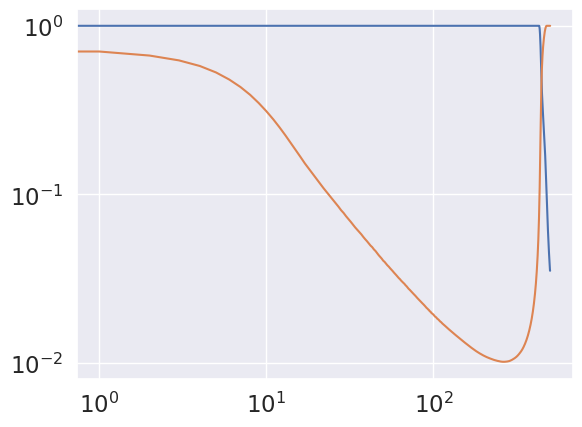

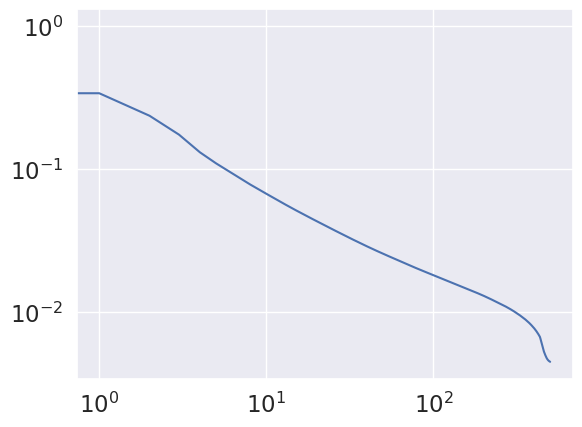

In [ ]:
eta_mat = result.x.reshape((T,2))

plt.loglog(eta_mat[:,0])
plt.loglog(eta_mat[:,1])
plt.show()

loss_dynamics = momentum_loss_dynamics(result.x.reshape((T,2)), m, spec, w_star, T, sigma)

plt.loglog(loss_dynamics)
plt.show()

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.05988645553588867
        x: [ 9.311e-01  7.502e-01 ...  1.304e-01  8.992e-01]
      nit: 97
      jac: [ 4.710e-07 -1.423e-06 ... -2.098e-06 -1.693e-06]
     nfev: 120
     njev: 120
 hess_inv: <64x64 LbfgsInvHessProduct with dtype=float64>


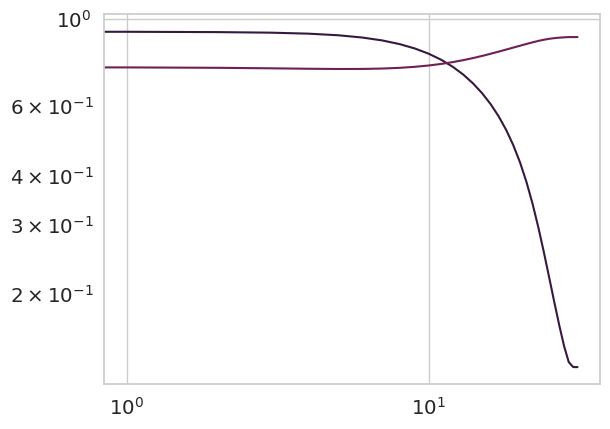

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.03858114033937454
        x: [ 9.173e-01  7.019e-01 ...  7.729e-02  8.429e-01]
      nit: 170
      jac: [ 1.009e-06  3.728e-07 ...  6.921e-06 -4.488e-06]
     nfev: 189
     njev: 189
 hess_inv: <128x128 LbfgsInvHessProduct with dtype=float64>


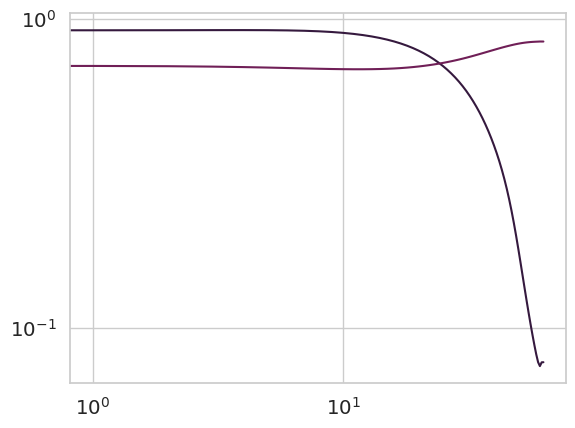

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.02529156766831875
        x: [ 8.944e-01  6.514e-01 ...  4.598e-02  7.853e-01]
      nit: 278
      jac: [ 1.220e-06 -1.037e-06 ... -3.035e-06 -2.617e-06]
     nfev: 305
     njev: 305
 hess_inv: <256x256 LbfgsInvHessProduct with dtype=float64>


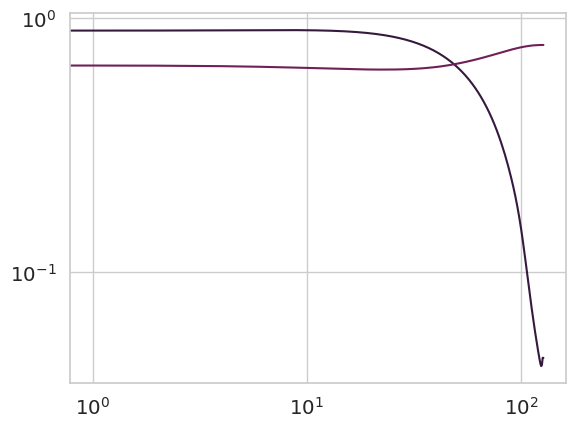

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.016772523522377014
        x: [ 8.598e-01  6.065e-01 ...  2.758e-02  7.283e-01]
      nit: 482
      jac: [ 1.302e-06  2.867e-08 ... -1.116e-06 -1.550e-07]
     nfev: 501
     njev: 501
 hess_inv: <512x512 LbfgsInvHessProduct with dtype=float64>


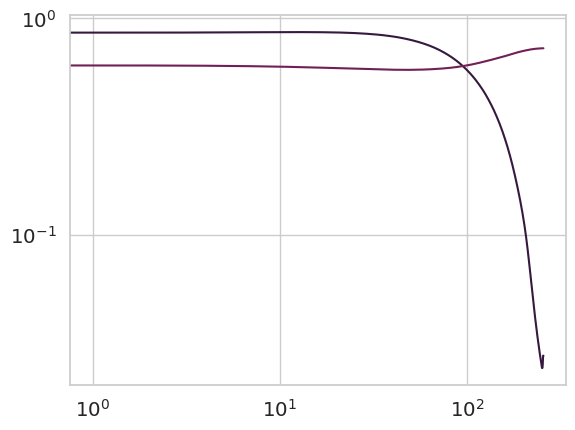

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.011207467876374722
        x: [ 8.131e-01  5.588e-01 ...  1.691e-02  6.491e-01]
      nit: 753
      jac: [ 4.637e-07  1.841e-07 ... -2.177e-07 -2.980e-08]
     nfev: 786
     njev: 786
 hess_inv: <1024x1024 LbfgsInvHessProduct with dtype=float64>


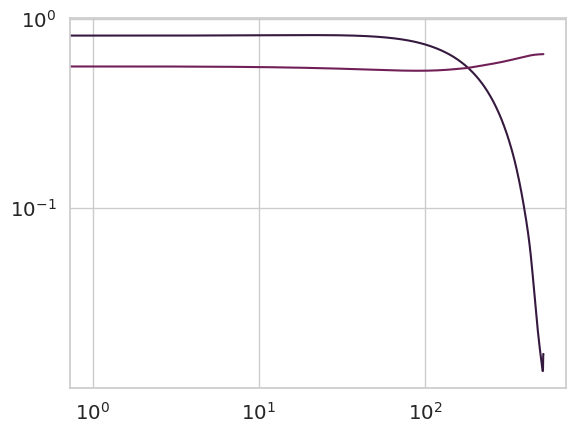

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.007525212597101927
        x: [ 7.573e-01  4.964e-01 ...  1.066e-02  5.457e-01]
      nit: 727
      jac: [-7.831e-09  6.163e-08 ... -1.972e-07  4.232e-07]
     nfev: 757
     njev: 757
 hess_inv: <2048x2048 LbfgsInvHessProduct with dtype=float64>


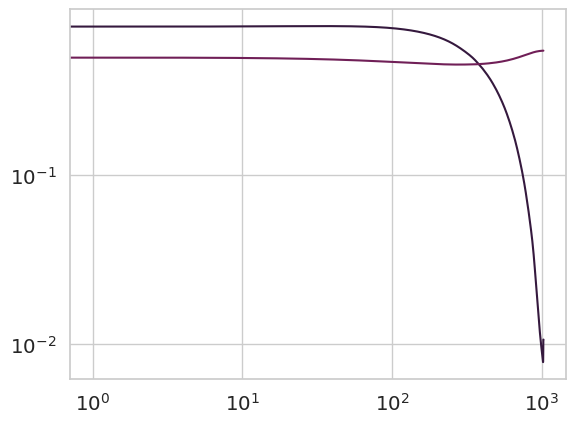

In [ ]:
Tvals = [32,64,128,256,512,1024]

N = 2000
a = 2.3
b = 1.75

spec = np.linspace(1,N,N)**(-b)
w_star = jnp.linspace(1,N,N)**(- (a-b)/2 )
w_star = w_star / jnp.sqrt( jnp.sum( w_star**2*spec ) )


sigma = 0.5

m = 4
eta = 1.0
beta = 0.5

all_eta_mat = []
all_loss = []
for i, T in enumerate(Tvals):

  eta_betas = np.zeros((T,2))

  eta_betas[:,0] = eta * np.ones(T)
  eta_betas[:,-1] = beta * np.ones(T)


  @jit
  def loss_fn_momentum(eta_betas, m, spec, w_star, sigma, kappa = 5e-2):
    eta_mat = eta_betas.reshape((T,2))
    loss_val = momentum_loss_dynamics(eta_mat, m, spec, w_star, T, sigma)[-1]
    reg = kappa * jnp.sum( (eta_mat[1:,:] - eta_mat[:-1, :])**2 )
    return loss_val + reg

  jac = jit(grad(loss_fn_momentum, 0))

  bounds = [(0, 1.0) for t in range(2*T)]

  x0 = eta_betas.reshape((2*T,))

  result = minimize(loss_fn_momentum, x0=x0, args = (m, spec, w_star, sigma) , jac=jac, bounds = bounds, tol=1e-12)
  print(result)

  eta_mat = result.x.reshape((T,2))

  plt.loglog(eta_mat[:,0])
  plt.loglog(eta_mat[:,1])
  plt.show()

  loss_dynamics = momentum_loss_dynamics(result.x.reshape((T,2)), m, spec, w_star, T, sigma)

  all_eta_mat += [eta_mat]
  all_loss += [loss_dynamics]


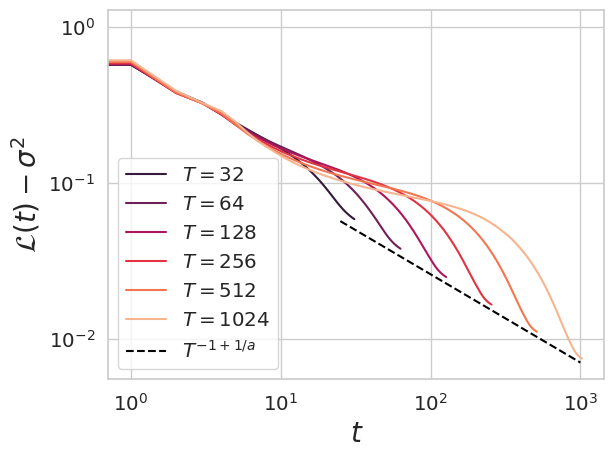

0.5652173913043478
0.7428571428571428


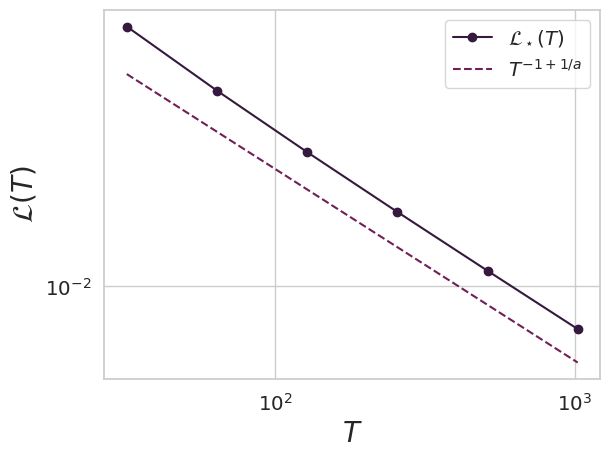

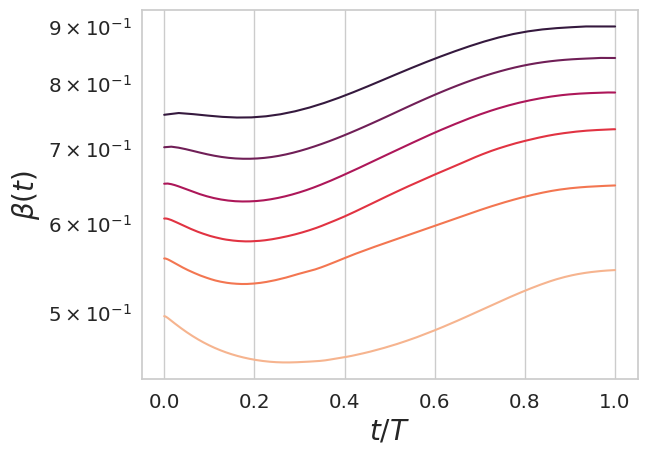

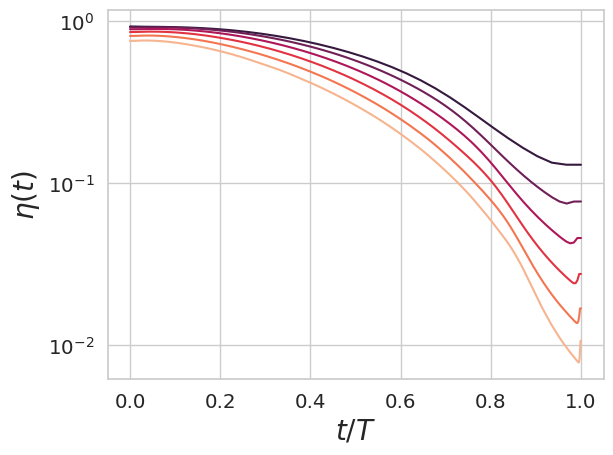

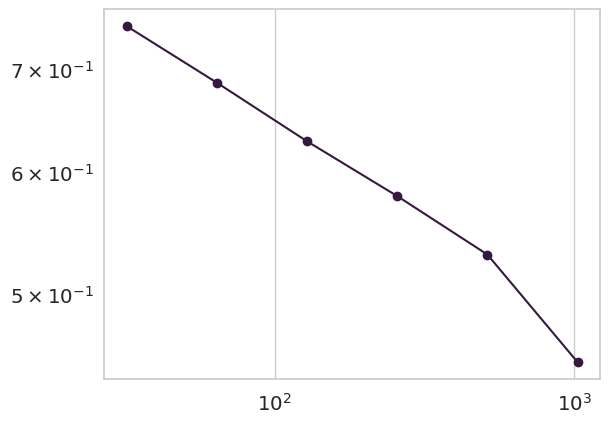

In [ ]:

sns.set(font_scale=1.3)
sns.set_style("whitegrid")
sns.set_palette("rocket", n_colors=len(Tvals))

for i, loss in enumerate(all_loss):
  plt.loglog(loss, label = r'$T = %d$' % Tvals[i])
plt.loglog(jnp.linspace(25,1000,100), 0.35*jnp.linspace(25,1000,100)**(-1+1/a), '--', color = 'black', label = r'$T^{-1+1/a}$')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t) - \sigma^2$',fontsize = 20)
plt.legend()
plt.savefig(r'loss_dynamics_opt_schedule_momentum_easy.pdf',bbox_inches = 'tight')
plt.show()

finals = [loss[-1] for loss in all_loss]

plt.loglog(Tvals, finals, '-o', label = r'$\mathcal{L}_\star(T)$')

print((a-1)/a)
print((a-1)/b)
#plt.loglog(Tvals, 0.3*jnp.array(Tvals)**(-(a-1)/b) , '--')
plt.loglog(Tvals, 0.3*jnp.array(Tvals)**(-(a-1)/a) , '--',label = r'$T^{-1+1/a}$')
plt.legend()
plt.xlabel(r'$T$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(T)$',fontsize = 20)
plt.show()

for i, eta_mat in enumerate(all_eta_mat):
  plt.semilogy(jnp.linspace(0,1,Tvals[i]), eta_mat[:,1])
plt.xlabel(r'$t/T$',fontsize = 20)
plt.ylabel(r'$\beta(t)$',fontsize = 20)
plt.savefig(r'beta_opt_schedule_momentum_easy.pdf',bbox_inches = 'tight')
plt.show()


for i, eta_mat in enumerate(all_eta_mat):
  #plt.loglog(eta_mat[:,0])
  plt.semilogy(jnp.linspace(0,1,Tvals[i]), eta_mat[:,0])

plt.xlabel(r'$t/T$',fontsize = 20)
plt.ylabel(r'$\eta(t)$',fontsize = 20)
plt.savefig(r'eta_opt_schedule_momentum_easy.pdf',bbox_inches = 'tight')
plt.show()

beta_min = [jnp.amin( eta_mat[:,1] ) for eta_mat in all_eta_mat]
plt.loglog(Tvals, beta_min,'-o')
plt.show()

## Hard Phase

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.5312375426292419
        x: [ 1.000e+00  7.141e-01 ...  3.325e-01  9.475e-01]
      nit: 63
      jac: [-9.420e-04  1.194e-05 ... -1.159e-05  9.370e-07]
     nfev: 81
     njev: 81
 hess_inv: <64x64 LbfgsInvHessProduct with dtype=float64>


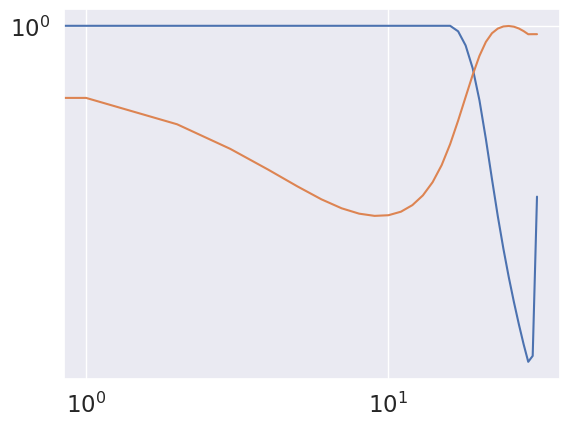

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.46957796812057495
        x: [ 1.000e+00  6.681e-01 ...  1.842e-01  9.170e-01]
      nit: 149
      jac: [-2.369e-04 -5.175e-06 ...  6.124e-06 -1.498e-05]
     nfev: 166
     njev: 166
 hess_inv: <128x128 LbfgsInvHessProduct with dtype=float64>


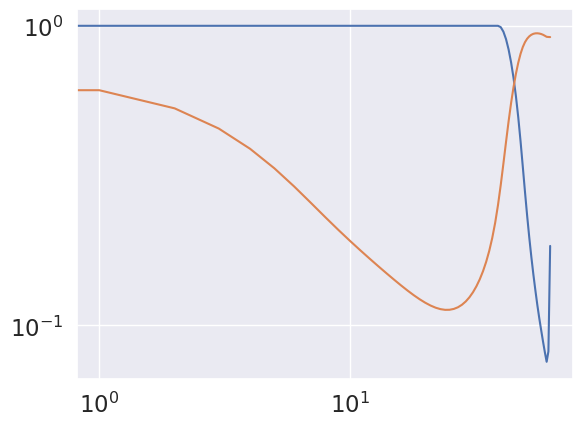

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.4167462885379791
        x: [ 1.000e+00  5.903e-01 ...  1.062e-01  9.121e-01]
      nit: 254
      jac: [-6.077e-05 -6.805e-06 ...  3.888e-06  2.949e-06]
     nfev: 296
     njev: 296
 hess_inv: <256x256 LbfgsInvHessProduct with dtype=float64>


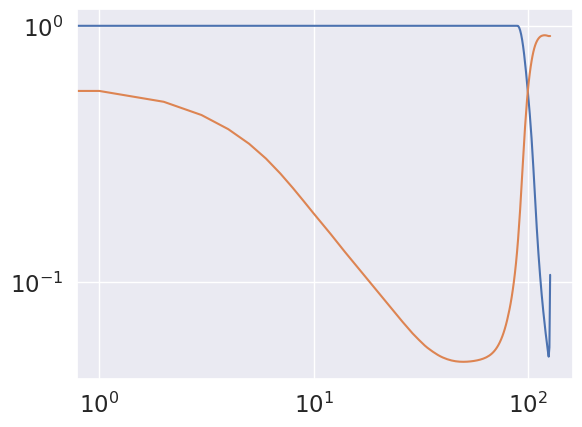

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.3707886338233948
        x: [ 1.000e+00  5.167e-01 ...  6.436e-02  8.690e-01]
      nit: 515
      jac: [-1.629e-05  1.346e-05 ... -1.307e-07  3.222e-06]
     nfev: 542
     njev: 542
 hess_inv: <512x512 LbfgsInvHessProduct with dtype=float64>


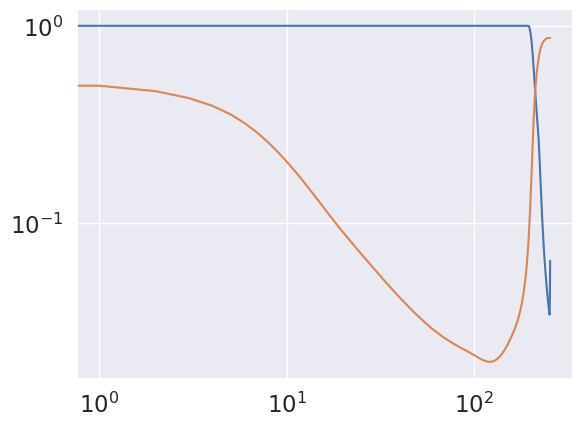

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.33032023906707764
        x: [ 1.000e+00  4.414e-01 ...  4.178e-02  7.842e-01]
      nit: 1353
      jac: [-4.603e-06 -1.122e-05 ... -1.156e-06  2.722e-06]
     nfev: 1430
     njev: 1430
 hess_inv: <1024x1024 LbfgsInvHessProduct with dtype=float64>


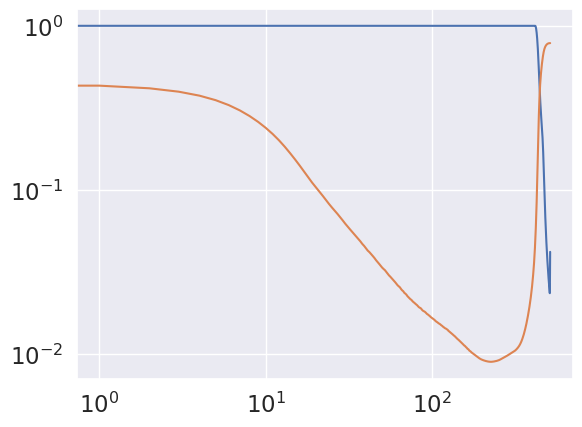

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.2943696677684784
        x: [ 1.000e+00  3.721e-01 ...  2.827e-02  7.219e-01]
      nit: 4383
      jac: [-1.442e-06  4.207e-06 ...  1.242e-07  1.205e-06]
     nfev: 4685
     njev: 4685
 hess_inv: <2048x2048 LbfgsInvHessProduct with dtype=float64>


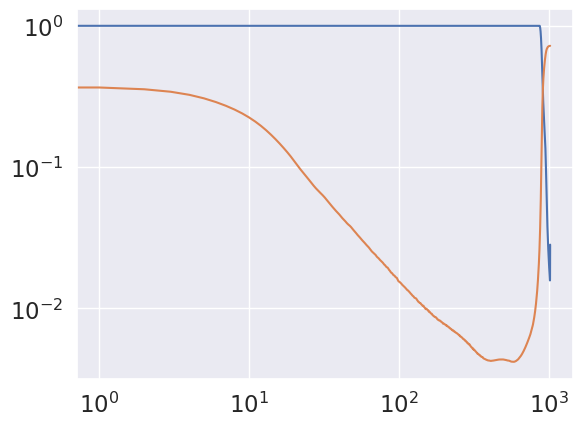

In [ ]:
Tvals = [32,64,128,256,512,1024]

N = 1500
a = 1.3
b = 2.75

spec = np.linspace(1,N,N)**(-b)
w_star = jnp.linspace(1,N,N)**(- (a-b)/2 )
w_star = w_star / jnp.sqrt( jnp.sum( w_star**2*spec ) )


sigma = 0.7

m = 4
eta = 0.9
beta = 0.9

all_eta_mat = []
all_loss = []
all_biases = []
for i, T in enumerate(Tvals):

  eta_betas = np.zeros((T,2))

  eta_betas[:,0] = eta * np.ones(T)
  eta_betas[:,-1] = beta * np.ones(T)


  @jit
  def loss_fn_momentum(eta_betas, m, spec, w_star, sigma, kappa = 1e-2):
    eta_mat = eta_betas.reshape((T,2))
    loss_val = momentum_loss_dynamics(eta_mat, m, spec, w_star, T, sigma)[-1]
    reg = kappa * jnp.sum( (eta_mat[1:,:] - eta_mat[:-1, :])**2 )
    return loss_val + reg


  jac = jit(grad(loss_fn_momentum, 0))

  bounds = [(0, 1.0) for t in range(2*T)]

  x0 = eta_betas.reshape((2*T,))

  result = minimize(loss_fn_momentum, x0=x0, args = (m, spec, w_star, sigma) , jac=jac, bounds = bounds, tol=1e-12)
  print(result)

  eta_mat = result.x.reshape((T,2))

  plt.loglog(eta_mat[:,0])
  plt.loglog(eta_mat[:,1])
  plt.show()

  loss_dynamics = momentum_loss_dynamics(result.x.reshape((T,2)), m, spec, w_star, T, sigma)
  bias = momentum_bias_dynamics(result.x.reshape((T,2)), m, spec, w_star, T, sigma)
  all_eta_mat += [eta_mat]
  all_loss += [loss_dynamics]
  all_biases += [ bias ]

0.10909090909090911
0.16363636363636366


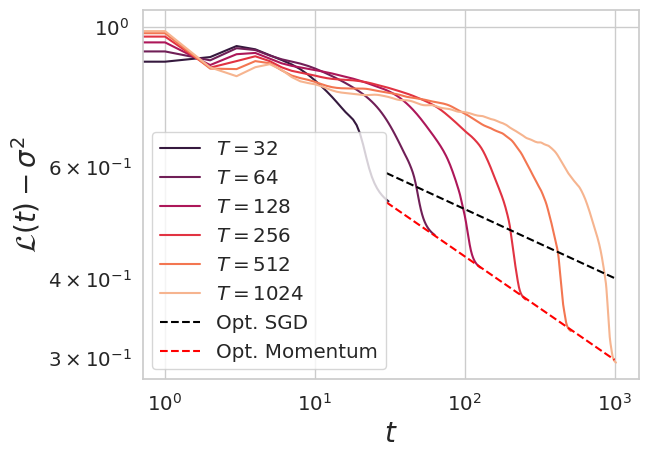

In [ ]:
sns.set(font_scale=1.3)
sns.set_style("whitegrid")
sns.set_palette("rocket", n_colors=len(Tvals))

print((a-1)/b)
print(1.5*(a-1)/b)
for i,loss in enumerate(all_loss):
  plt.loglog(loss, label = r'$T = %d$' % Tvals[i])
  #plt.loglog(all_biases[i], '--')
tgrid = jnp.linspace(30, 1000, 100)
plt.loglog(tgrid, 0.85*tgrid**(-(a-1)/b) , '--', color = 'black', label = r'Opt. SGD')
plt.loglog(tgrid, 0.92*tgrid**(-1.5*(a-1)/b), '--', color = 'red', label = 'Opt. Momentum')
#plt.loglog(tgrid, 0.9*tgrid**(-1.5*(a-1)/b), '--', color = 'red', label = r'$T^{%0.1f}$' %  )
#plt.loglog(tgrid, 0.9*tgrid**(-(a-1)/a), '--', color = 'red')
plt.legend()
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t) - \sigma^2$',fontsize = 20)
plt.savefig(r'optimal_control_momentum_hard_phase_scaling.pdf',bbox_inches = 'tight')
plt.show()


0.23076923076923078
0.10909090909090911


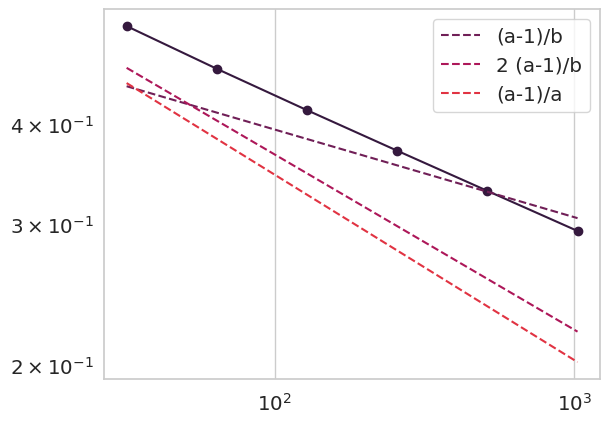

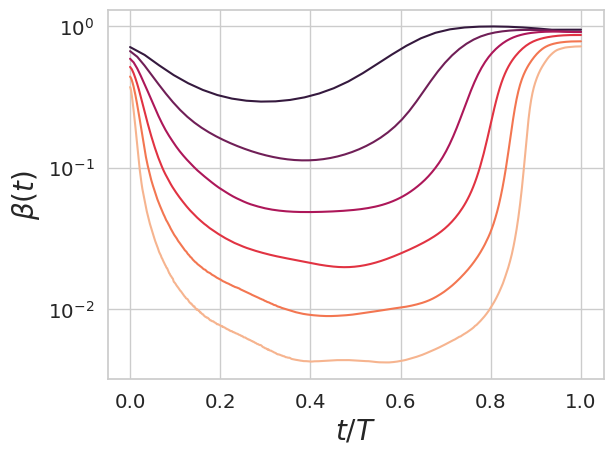

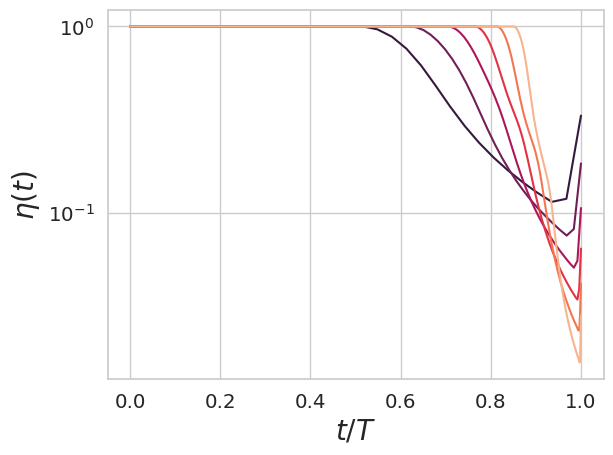

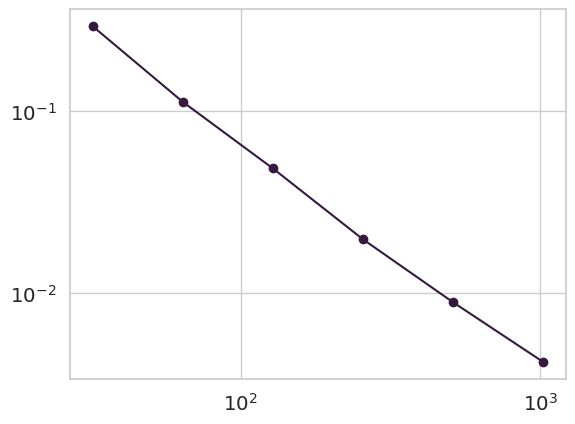

In [ ]:

finals = [loss[-1] for loss in all_loss]

plt.loglog(Tvals, finals, '-o')

print((a-1)/a)
print((a-1)/b)
plt.loglog(Tvals, 0.65*jnp.array(Tvals)**(-(a-1)/b) , '--', label = '(a-1)/b')
plt.loglog(Tvals, 1.0*jnp.array(Tvals)**(-2*(a-1)/b) , '--', label = '2 (a-1)/b')
plt.loglog(Tvals, 1.0*jnp.array(Tvals)**(-(a-1)/a) , '--', label = '(a-1)/a')

plt.legend()
#plt.loglog(Tvals, 0.5*jnp.array(Tvals)**(-(a-1)/a) , '--')
plt.show()

for i, eta_mat in enumerate(all_eta_mat):
  plt.semilogy(jnp.linspace(0,1,Tvals[i]), eta_mat[:,1])
plt.xlabel(r'$t/T$',fontsize = 20)
plt.ylabel(r'$\beta(t)$',fontsize = 20)
plt.savefig(r'beta_opt_schedule_momentum_hard_phase.pdf',bbox_inches = 'tight')
plt.show()


for i, eta_mat in enumerate(all_eta_mat):
  #plt.loglog(eta_mat[:,0])
  plt.semilogy(jnp.linspace(0,1,Tvals[i]), eta_mat[:,0])
plt.xlabel(r'$t/T$',fontsize = 20)
plt.ylabel(r'$\eta(t)$',fontsize = 20)
plt.savefig(r'eta_opt_schedule_momentum_hard_phase.pdf',bbox_inches = 'tight')
plt.show()

beta_min = [jnp.amin( eta_mat[:,1] ) for eta_mat in all_eta_mat]
plt.loglog(Tvals, beta_min,'-o')
plt.show()

## Optimize Bias Dynamics

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.5206537842750549
        x: [ 1.000e+00  6.130e-01 ...  1.000e+00  0.000e+00]
      nit: 70
      jac: [-2.076e-03 -8.279e-06 ...  0.000e+00  0.000e+00]
     nfev: 106
     njev: 106
 hess_inv: <64x64 LbfgsInvHessProduct with dtype=float64>


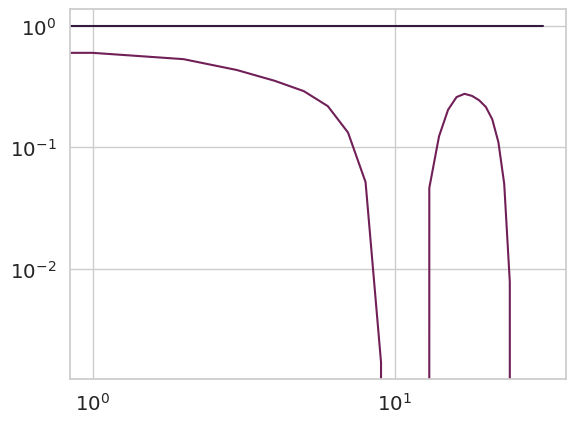

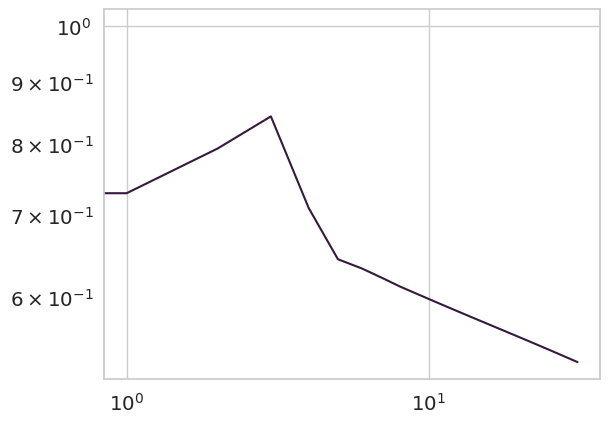

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.48120176792144775
        x: [ 1.000e+00  5.629e-01 ...  1.000e+00  0.000e+00]
      nit: 41
      jac: [-6.793e-04  2.366e-05 ...  0.000e+00 -2.783e-17]
     nfev: 68
     njev: 68
 hess_inv: <128x128 LbfgsInvHessProduct with dtype=float64>


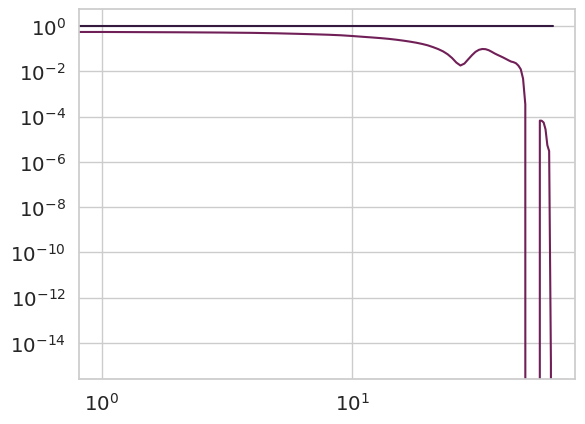

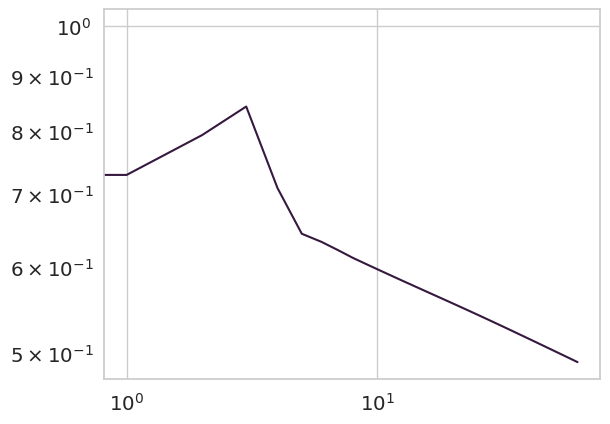

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.44865497946739197
        x: [ 1.000e+00  9.071e-01 ...  1.000e+00  8.996e-01]
      nit: 9
      jac: [-3.611e-04 -1.076e-05 ...  0.000e+00  2.224e-06]
     nfev: 29
     njev: 29
 hess_inv: <256x256 LbfgsInvHessProduct with dtype=float64>


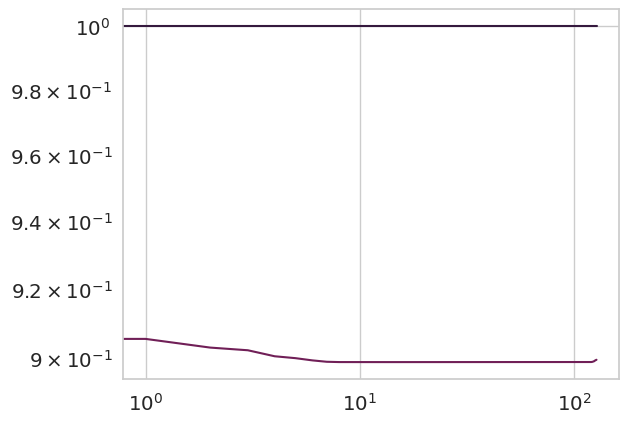

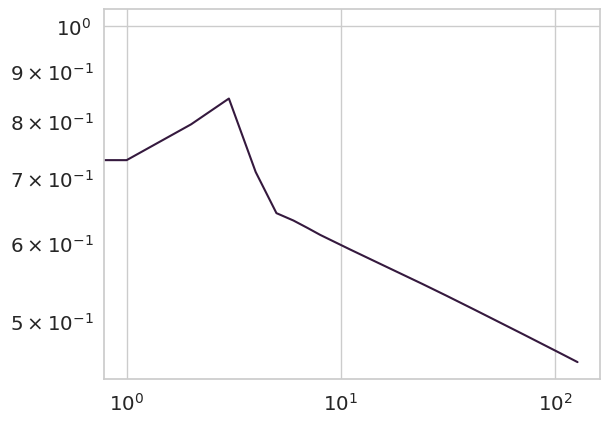

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.4142001271247864
        x: [ 1.000e+00  9.047e-01 ...  1.000e+00  8.998e-01]
      nit: 10
      jac: [-1.696e-04 -6.323e-06 ...  0.000e+00  5.186e-07]
     nfev: 26
     njev: 26
 hess_inv: <512x512 LbfgsInvHessProduct with dtype=float64>


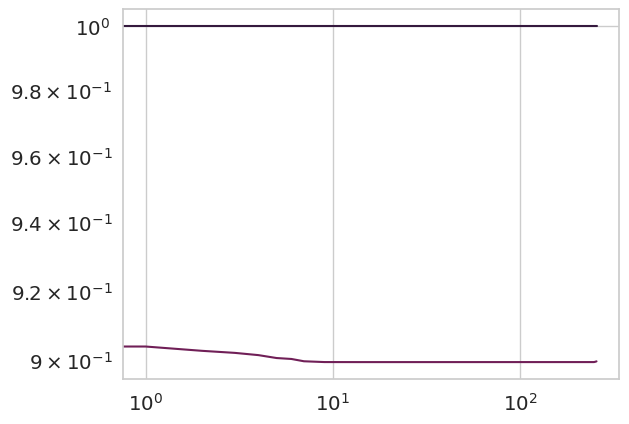

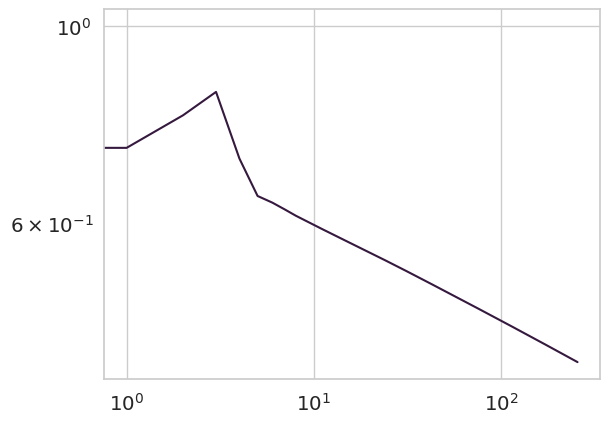

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.3817574381828308
        x: [ 1.000e+00  9.031e-01 ...  9.999e-01  8.999e-01]
      nit: 10
      jac: [-7.989e-05 -2.177e-08 ... -1.369e-06 -1.431e-08]
     nfev: 29
     njev: 29
 hess_inv: <1024x1024 LbfgsInvHessProduct with dtype=float64>


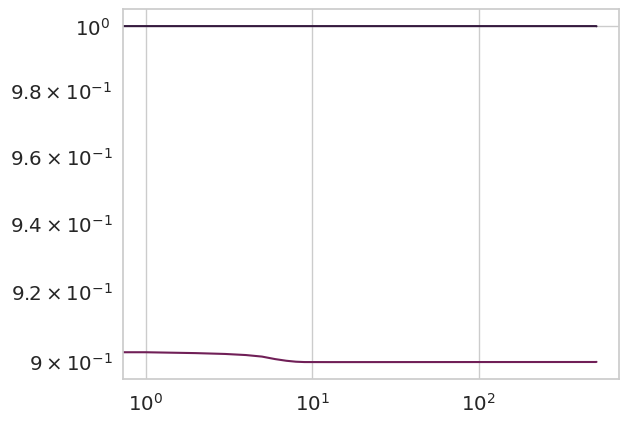

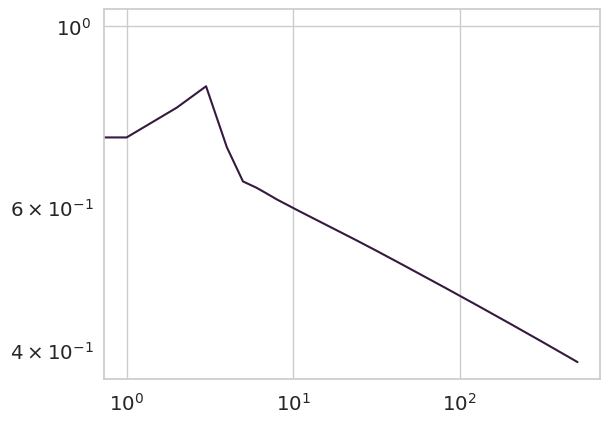

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.3511728346347809
        x: [ 1.000e+00  9.019e-01 ...  1.000e+00  8.999e-01]
      nit: 12
      jac: [-3.767e-05 -3.499e-06 ...  0.000e+00 -3.695e-08]
     nfev: 29
     njev: 29
 hess_inv: <2048x2048 LbfgsInvHessProduct with dtype=float64>


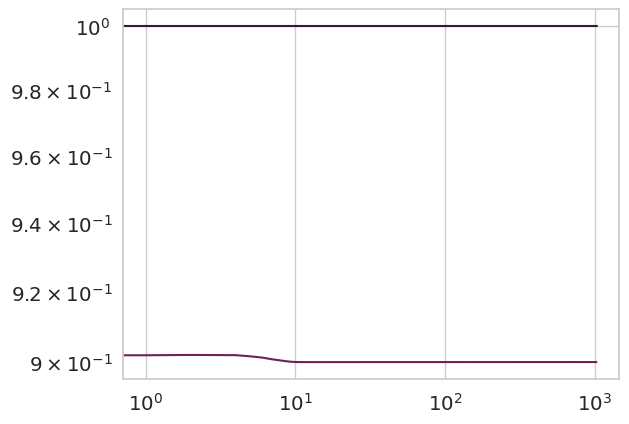

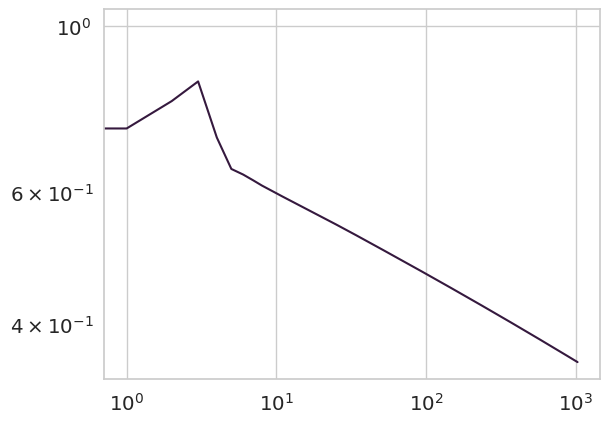

In [ ]:
Tvals = [32,64,128,256,512,1024]

N = 1500
a = 1.25
b = 3.0

spec = jnp.linspace(1,N,N)**(-b)
w_star = jnp.linspace(1,N,N)**(- (a-b)/2 )
w_star = w_star / jnp.sqrt( jnp.sum( w_star**2*spec ) )


sigma = 0.7

m = 4
eta = 0.9
beta = 0.9

all_eta_mat = []
all_loss = []
all_biases = []
bias_powerlaws = []
for i, T in enumerate(Tvals):

  eta_betas = np.zeros((T,2))

  eta_betas[:,0] = eta * np.ones(T)
  eta_betas[:,-1] = beta * np.ones(T)


  @jit
  def loss_fn_momentum(eta_betas, m, spec, w_star, sigma, kappa = 1e-2):
    eta_mat = eta_betas.reshape((T,2))
    loss_val = momentum_bias_dynamics(eta_mat, m, spec, w_star, T, sigma)[-1]
    reg = kappa * jnp.sum( (eta_mat[1:,:] - eta_mat[:-1, :])**2 )
    return loss_val + reg


  jac = jit(grad(loss_fn_momentum, 0))

  bounds = [(0, 1.0) for t in range(2*T)]

  x0 = eta_betas.reshape((2*T,))

  result = minimize(loss_fn_momentum, x0=x0, args = (m, spec, w_star, sigma) , jac=jac, bounds = bounds, tol=1e-12)
  print(result)

  eta_mat = result.x.reshape((T,2))

  plt.loglog(eta_mat[:,0])
  plt.loglog(eta_mat[:,1])
  plt.show()

  loss_dynamics = momentum_loss_dynamics(result.x.reshape((T,2)), m, spec, w_star, T, sigma)
  bias = momentum_bias_dynamics(result.x.reshape((T,2)), m, spec, w_star, T, sigma)
  all_eta_mat += [eta_mat]
  all_loss += [loss_dynamics]
  all_biases += [ bias ]


  eta_betas[:,0] = eta * np.ones(T)
  eta_betas[:,-1] = beta * ( 1.0 - np.linspace(1,T,T)**(-1.0) )
  bias_power = momentum_bias_dynamics(eta_betas, m, spec, w_star, T, sigma)

  plt.loglog(bias_power)
  plt.show()
  bias_powerlaws += [ bias_power ]

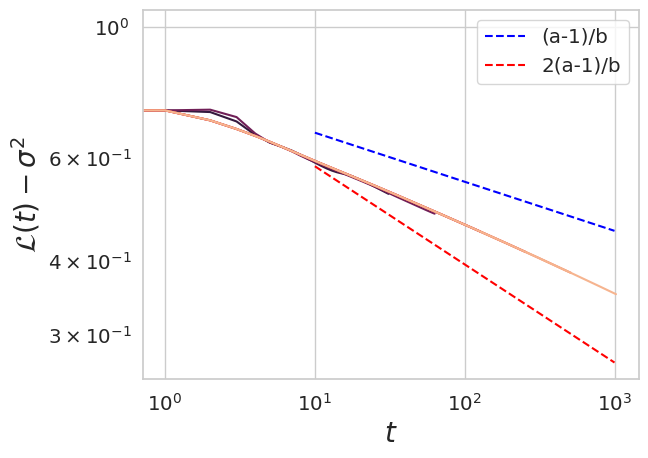

In [ ]:
sns.set(font_scale=1.3)
sns.set_style("whitegrid")
sns.set_palette("rocket", n_colors=len(Tvals))

for i,loss in enumerate(all_loss):
  #plt.loglog(loss, label = r'$T = %d$' % Tvals[i])
  plt.loglog(all_biases[i])
  #plt.loglog(bias_powerlaws[i], '--')
tgrid = jnp.linspace(10, 1000, 100)
plt.loglog(tgrid, 0.8*tgrid**(-(a-1)/b) , '--', color = 'blue', label = '(a-1)/b')
plt.loglog(tgrid, 0.85*tgrid**(-2*(a-1)/b), '--', color = 'red', label = '2(a-1)/b')
plt.legend()
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t) - \sigma^2$',fontsize = 20)
plt.show()


## Learning Rate Transfer

In [ ]:
N = 2000
a = 2.3
b = 1.75

spec = np.linspace(1,N,N)**(-b)
w_star = jnp.linspace(1,N,N)**(- (a-b)/2 )
w_star = w_star / jnp.sqrt( jnp.sum( w_star**2*spec ) )


sigma = 0.5

m = 8

beta = 0.9

Tvals = [128,256,512, 1024, 2048, 4096, 8192]


eta_vals = jnp.logspace(-2, 0.25, 100)

# all_loss = []
# for i, T in enumerate(Tvals):

#   all_loss_i = []
#   for j, eta in enumerate(eta_vals):
#     eta_mat = np.zeros((T,2))

#     eta_mat[:,0] = eta * np.ones(T)
#     eta_mat[:,-1] = beta * np.ones(T)

#     loss_val = momentum_loss_dynamics(eta_mat, m, spec, w_star, T, sigma)

#     all_loss_i += [loss_val]

#   all_loss += [all_loss_i]


all_loss = []
for i, T in enumerate(Tvals):

  all_loss_i = []
  for j, eta in enumerate(eta_vals):

    eta_mat = eta * np.ones(T)

    loss_val = sgd_loss_dynamics(eta_mat, m, spec, w_star, T, sigma)

    all_loss_i += [loss_val]

  all_loss += [all_loss_i]

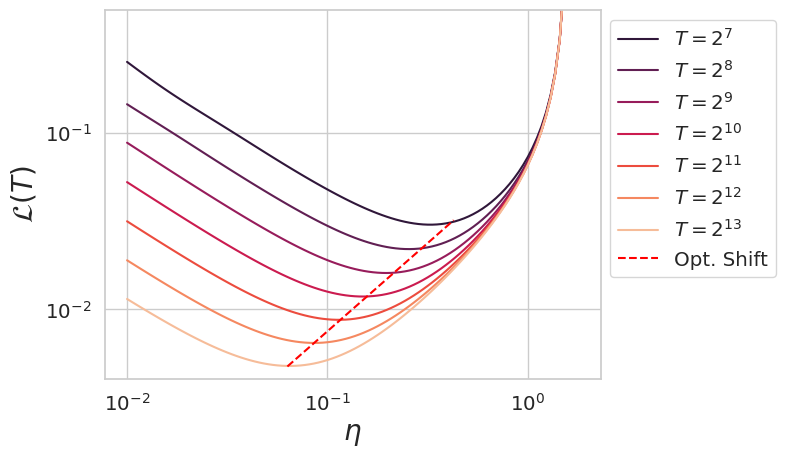

In [ ]:

sns.set(font_scale=1.3)
sns.set_style("whitegrid")
sns.set_palette("rocket", n_colors=len(Tvals))

eta_min =[]
for i, loss_i in enumerate(all_loss):
  plt.loglog(eta_vals, [loss[-1] for loss in loss_i], label = r'$T = 2^{%d}$' % jnp.log2(Tvals[i]+10))

  indmin = jnp.argmin(jnp.array( [loss[-1] for loss in loss_i]  ) )
  eta_min += [eta_vals[indmin]]

eta_grid = jnp.logspace(-1.2,-0.37,10)
plt.loglog(eta_grid, 0.075*eta_grid, '--', color = 'red', label = 'Opt. Shift')
plt.ylim([4e-3,0.5])
#plt.xlim([1e-1,1.25])
plt.legend(bbox_to_anchor=(1, 1))
plt.xlabel(r'$\eta$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(T)$',fontsize = 20)
plt.savefig(r'loss_vs_tokens_sgd_fixed_LR.pdf',bbox_inches = 'tight')
plt.show()


#

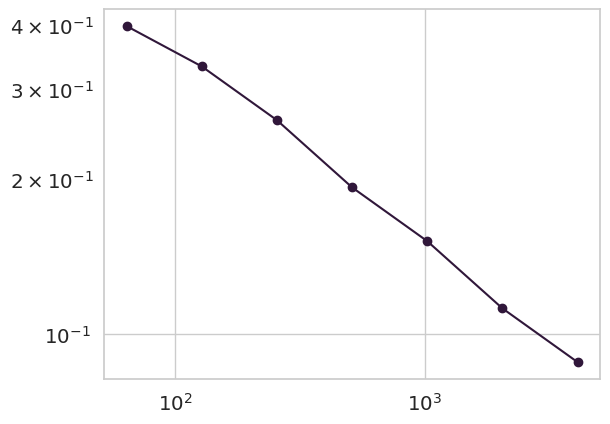

In [ ]:
plt.loglog(Tvals, eta_min,'-o')

plt.show()